## MultiEYE: Implementation of Cross Modal Knowledge Distillation
---
by Wang et al., IEEE Transactions on Medical Imaging, Vol. 44, No. 4, April, 2025

In [1]:
import subprocess
subprocess.run([
    "pip", "install", "git+https://github.com/jusiro/FLAIR.git"
], check=True)
print("FLAIR installed")

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/jusiro/FLAIR.git to /tmp/pip-req-build-0s8bqaq2


  Running command git clone --filter=blob:none --quiet https://github.com/jusiro/FLAIR.git /tmp/pip-req-build-0s8bqaq2


  Resolved https://github.com/jusiro/FLAIR.git to commit d6652d53389ff49e5f73efaccf4246e9de88d1a3
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'canceled'


ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [1]:
import os
# Limit CPU threads so you don't compete with other cluster users
os.environ["OMP_NUM_THREADS"]        = "4"
os.environ["MKL_NUM_THREADS"]        = "4"
os.environ["OPENBLAS_NUM_THREADS"]   = "4"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
torch.set_num_threads(4)
torch.set_num_interop_threads(2)

print(f"CPU threads : {torch.get_num_threads()}")
print(f"Interop     : {torch.get_num_interop_threads()}")

CPU threads : 4
Interop     : 2


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import torchvision.transforms as transforms
from transformers import AutoModel, AutoProcessor
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, cohen_kappa_score,
                             average_precision_score)
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm
import warnings
from PIL import Image
import os
import gc
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
GPU: NVIDIA H200
VRAM: 139.8 GB


In [4]:
concepts_path = "/nfsshare/users/P127156071/datasets/MultiEYE/concepts_raw.npy"
concepts_raw  = np.load(concepts_path, allow_pickle=True)
concept_texts = [str(c).strip() for c in concepts_raw.flatten() if str(c).strip()]
print(f"Loaded {len(concept_texts)} concepts from {concepts_path}")
print("Sample concepts:", concept_texts[:3])

Loaded 98 concepts from /nfsshare/users/P127156071/datasets/MultiEYE/concepts_raw.npy
Sample concepts: ['retinal wrinkling: the retina beneath the membrane appears wrinkled or puckered', 'vessel distortion: blood vessels on the retinal surface may appear twisted or distorted', 'retinal elevation: the retina appears lifted or bulging due to fluid underneath']


In [5]:
# ====================== GLOBAL CONFIG ======================
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

num_classes    = 9
teacher_epochs = 80
student_epochs = 100
alpha          = 0.6    # GPD loss weight  (paper default)
beta           = 0.05   # LCD loss weight  (paper default)
tau            = 10.0   # temperature      (paper default)

# --- FLAIR backbone ---
MODEL_NAME = "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
# If you have FLAIR weights locally, replace with the local path:
# MODEL_NAME = "/path/to/flair/weights"

# --- Batch size & accumulation (target effective batch = 64) ---
# Tune batch_size down until no OOM; ACCUM_STEPS adjusts automatically
# 512x512 inputs (FLAIR) are ~5x heavier than 224x224 (CLIP)
#
#   VRAM  |  batch_size  |  ACCUM_STEPS
#   6 GB  |      1       |     64
#   8 GB  |      2       |     32
#  16 GB  |      4       |     16
#  24 GB  |      8       |      8
#
batch_size   = 4     # single value used for both teacher and student
ACCUM_STEPS  = 16    # effective batch = batch_size × ACCUM_STEPS = 64

print(f"Effective batch size = {batch_size} x {ACCUM_STEPS} = {batch_size * ACCUM_STEPS}")

Effective batch size = 4 x 16 = 64


In [6]:
# FLAIR normalization stats (from jusiro/FLAIR repo)
FLAIR_MEAN = [0.3898, 0.2467, 0.1508]
FLAIR_STD  = [0.2828, 0.1947, 0.1497]

fundus_train_transform = transforms.Compose([
    transforms.Resize((560, 560)),
    transforms.RandomCrop(512),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=FLAIR_MEAN, std=FLAIR_STD)
])

oct_train_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=FLAIR_MEAN, std=FLAIR_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=FLAIR_MEAN, std=FLAIR_STD)
])

In [7]:
class MultiEyeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return {
            'image': img,
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [8]:
# Data Paths and Loading
DATA_ROOT = "/nfsshare/users/P127156071/datasets/MultiEYE/multieye_data/"

fundus_img_dir  = os.path.join(DATA_ROOT, "assemble/train/ImageData/cfp-clahe-224x224")
oct_img_dir     = os.path.join(DATA_ROOT, "assemble_oct/train/ImageData/oct-filter-448x448")

fundus_train_lbl = os.path.join(DATA_ROOT, "assemble/train/large9cls.txt")
fundus_dev_lbl   = os.path.join(DATA_ROOT, "assemble/dev/large9cls.txt")
oct_train_lbl    = os.path.join(DATA_ROOT, "assemble_oct/train/large9cls.txt")
oct_dev_lbl      = os.path.join(DATA_ROOT, "assemble_oct/dev/large9cls.txt")

def load_paths_and_labels(lbl_file, img_dir):
    paths, labels = [], []
    with open(lbl_file, 'r') as f:
        for line in f:
            parts   = line.strip().split()
            img_id  = parts[0]
            label   = int(parts[1])
            for ext in ['.png', '.jpg', '.jpeg']:
                p = os.path.join(img_dir, img_id + ext)
                if os.path.exists(p):
                    paths.append(p)
                    labels.append(label)
                    break
    return paths, labels

fundus_train_paths, fundus_train_labels = load_paths_and_labels(fundus_train_lbl, fundus_img_dir)
fundus_val_paths,   fundus_val_labels   = load_paths_and_labels(fundus_dev_lbl,   fundus_img_dir)
oct_train_paths,    oct_train_labels    = load_paths_and_labels(oct_train_lbl,    oct_img_dir)
oct_val_paths,      oct_val_labels      = load_paths_and_labels(oct_dev_lbl,      oct_img_dir)

# Remove OCT val leakage
train_set = set(os.path.basename(p) for p in oct_train_paths)
clean_val_paths, clean_val_labels = [], []
for p, l in zip(oct_val_paths, oct_val_labels):
    if os.path.basename(p) not in train_set:
        clean_val_paths.append(p)
        clean_val_labels.append(l)

print(f"Fundus train: {len(fundus_train_paths)} | val: {len(fundus_val_paths)}")
print(f"OCT    train: {len(oct_train_paths)}    | val: {len(clean_val_paths)}")

KeyboardInterrupt: 

In [10]:
# Class Weights
def get_class_weights(labels, n_classes=9):
    counts  = Counter(labels)
    weights = [len(labels) / (n_classes * counts[i]) for i in range(n_classes)]
    return torch.tensor(weights, dtype=torch.float32).to(device)

class_weights = get_class_weights(fundus_train_labels)
print("Class weights:", [f"{w:.3f}" for w in class_weights.tolist()])

Class weights: ['0.169', '3.317', '41.175', '0.440', '6.183', '24.190', '11.836', '10.546', '9.652']


In [11]:
fundus_train_dataset = MultiEyeDataset(fundus_train_paths, fundus_train_labels, fundus_train_transform)
fundus_val_dataset   = MultiEyeDataset(fundus_val_paths,   fundus_val_labels,   val_transform)
oct_train_dataset    = MultiEyeDataset(oct_train_paths,    oct_train_labels,    oct_train_transform)
oct_val_dataset      = MultiEyeDataset(clean_val_paths,    clean_val_labels,    val_transform)

fundus_train_loader = DataLoader(fundus_train_dataset, batch_size=batch_size,
                                  shuffle=True,  num_workers=2, pin_memory=False)
fundus_val_loader   = DataLoader(fundus_val_dataset,   batch_size=batch_size,
                                  shuffle=False, num_workers=2, pin_memory=False)
oct_train_loader    = DataLoader(oct_train_dataset,    batch_size=batch_size,
                                  shuffle=True,  num_workers=2, pin_memory=False)
oct_val_loader      = DataLoader(oct_val_dataset,      batch_size=batch_size,
                                  shuffle=False, num_workers=2, pin_memory=False)

print(f"Fundus train batches: {len(fundus_train_loader)} | val batches: {len(fundus_val_loader)}")
print(f"OCT    train batches: {len(oct_train_loader)}    | val batches: {len(oct_val_loader)}")

Fundus train batches: 8709 | val batches: 2901
OCT    train batches: 9181    | val batches: 2285


In [9]:
from flair import FLAIRModel

class ConceptModel(nn.Module):
    def __init__(self, num_classes, concept_texts, model_name="jusiro2/FLAIR"):
        super().__init__()

        self.flair = FLAIRModel.from_pretrained(model_name)
        self.flair = self.flair.to(device)

        # Disable the default "A fundus photograph of [CLS]" template
        # so GPT-generated concept texts are used as-is
        self.flair.caption = "[CLS]"

        # Freeze text encoder (BioClinicalBERT)
        for param in self.flair.text_model.parameters():
            param.requires_grad = False

        # Pre-compute and cache concept embeddings (frozen throughout training)
        with torch.no_grad():
            # preprocess_text tokenizes and moves to device internally
            input_ids, attention_mask = self.flair.preprocess_text(concept_texts)

            # text_model returns raw projected embeddings — NOT normalized
            text_features    = self.flair.text_model(input_ids, attention_mask)  # [N, proj_dim]
            self.concept_emb = F.normalize(text_features, dim=-1)                # [N, proj_dim]

        self.num_concepts = len(concept_texts)
        self.classifier   = nn.Linear(self.num_concepts, num_classes).to(device)

    def get_image_features(self, images):
        # images: tensor [B, C, H, W] — already preprocessed by DataLoader
        # vision_model returns raw projected embeddings — NOT normalized
        v = self.flair.vision_model(images)   # [B, proj_dim]
        return F.normalize(v, dim=-1)         # [B, proj_dim]

    def get_concept_similarity(self, images):
        v = self.get_image_features(images)   # [B, proj_dim]
        s = v @ self.concept_emb.T            # [B, N_concepts] — cosine similarity
        return s

    def forward(self, images):
        s      = self.get_concept_similarity(images)
        logits = self.classifier(s)
        return logits, s

In [13]:
def gpd_loss(s_f, labels_f, s_o, labels_o):
    """
    Global Prototypical Distillation — paper Eq. 5-6.
    Aligns class-level concept prototypes between OCT teacher and fundus student.
    Only computes over classes present in BOTH modalities within the batch.
    """
    loss  = 0.0
    count = 0

    unique_f     = set(labels_f.cpu().tolist())
    unique_o     = set(labels_o.cpu().tolist())
    shared_cls   = unique_f & unique_o

    for d in shared_cls:
        mask_f = (labels_f == d)
        mask_o = (labels_o == d)
        e_f    = s_f[mask_f].mean(dim=0)
        e_o    = s_o[mask_o].mean(dim=0)
        loss  += torch.sum((e_o - e_f) ** 2)   # ||e_o - e_f||^2  (paper Eq. 6)
        count += 1

    return loss / count if count > 0 else torch.tensor(0.0, device=s_f.device)


def lcd_loss(s_f, labels_f, s_o, labels_o, tau=10.0):
    """
    Local Contrastive Distillation — paper Eq. 7.
    Anchors: fundus samples only (i in 1..B_f)
    Positives P_i: same-class samples from BOTH fundus and OCT, excluding anchor itself
    Denominator: all q in pool except the specific positive p being evaluated,
                 and excluding the anchor itself
    """
    s_all      = torch.cat([s_f, s_o], dim=0)          # [B_f + B_o, N_concepts]
    labels_all = torch.cat([labels_f, labels_o], dim=0)
    B_f        = s_f.shape[0]
    total_loss = 0.0
    count      = 0

    for i in range(B_f):
        label_i  = labels_f[i]

        # Build positive mask: same class, exclude anchor itself
        pos_mask    = (labels_all == label_i)
        pos_mask[i] = False                              # FIX 1: exclude anchor
        pos_indices = torch.where(pos_mask)[0]

        if len(pos_indices) == 0:                        # FIX 2: guard is == 0 not <= 1
            continue

        sim_i       = (s_f[i] @ s_all.T) / tau          # [B_f + B_o]
        exp_sim     = torch.exp(sim_i)
        denom_total = exp_sim.sum() - exp_sim[i]         # FIX 3: exclude anchor from pool

        for p_idx in pos_indices:
            denom    = denom_total - exp_sim[p_idx] + 1e-8   # exclude specific positive
            log_prob = sim_i[p_idx] - torch.log(denom)
            total_loss += log_prob
            count      += 1.0

    return -total_loss / count if count > 0 else torch.tensor(0.0, device=s_f.device)

In [10]:
def compute_paper_metrics(y_true, y_pred, y_prob=None, n_classes=9):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_true, y_pred,    average='macro', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    pr_f1 = f1_score(y_true, y_pred,        average='macro', zero_division=0)

    # Per-class sensitivity & specificity → macro S-S F1
    ss_f1_list = []
    spec_list  = []
    for cls in range(n_classes):
        tp   = ((y_true == cls) & (y_pred == cls)).sum()
        fn   = ((y_true == cls) & (y_pred != cls)).sum()
        tn   = ((y_true != cls) & (y_pred != cls)).sum()
        fp   = ((y_true != cls) & (y_pred == cls)).sum()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        spec_list.append(spec)
        ss_f1_list.append(2 * sens * spec / (sens + spec + 1e-8))

    spec_macro = np.mean(spec_list)
    ss_f1      = np.mean(ss_f1_list)

    map_score = average_precision_score(
        np.eye(n_classes)[y_true], y_prob, average='macro'
    ) if y_prob is not None else 0.0

    return {
        'Precision':   round(prec,       4),
        'Recall':      round(rec,        4),
        'Specificity': round(spec_macro, 4),
        'P-R F1':      round(pr_f1,      4),
        'S-S F1':      round(ss_f1,      4),
        'MAP':         round(map_score,  4),
        'Accuracy':    round(acc,        4),
        'Kappa':       round(kappa,      4)
    }

In [11]:
@torch.no_grad()
def evaluate(model, loader, device, phase="Validation"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss  = 0.0
    num_samples = 0

    for batch in tqdm(loader, desc=f"{phase}", leave=False):
        imgs   = batch['image'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        logits, _ = model(imgs)
        loss      = F.cross_entropy(logits, labels)

        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        total_loss  += loss.item() * imgs.size(0)
        num_samples += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / num_samples
    metrics  = compute_paper_metrics(all_labels, all_preds, np.array(all_probs))
    metrics['Val_Loss'] = round(avg_loss, 4)
    return metrics

In [12]:
def load_latest_checkpoint(model, optimizer, scheduler=None, phase="teacher"):
    ckpt_path  = f"{CHECKPOINT_DIR}/{phase}_latest.pth"
    sched_path = f"{CHECKPOINT_DIR}/{phase}_scheduler.pth"

    if os.path.exists(ckpt_path):
        print(f"Resuming {phase} from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        start_epoch = ckpt['epoch'] + 1

        if scheduler is not None and os.path.exists(sched_path):
            scheduler.load_state_dict(
                torch.load(sched_path, map_location='cpu', weights_only=True)
            )
            print(f"   → Scheduler state restored")

        print(f"   → Resuming from epoch {start_epoch}")
        return start_epoch
    return 1

In [17]:
def plot_curves(results, phase="Teacher"):
    epochs = [r['Epoch']      for r in results]
    loss   = [r['Train_Loss'] for r in results]
    pr_f1  = [r['P-R F1']    for r in results]
    acc    = [r['Accuracy']   for r in results]
    lr     = [r['LR']         for r in results]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].plot(epochs, loss,  marker='o', color='steelblue')
    axes[0].set_title(f'{phase} — Training Loss')
    axes[0].set_xlabel('Epoch')

    axes[1].plot(epochs, pr_f1, marker='o', color='green')
    axes[1].set_title(f'{phase} — Validation P-R F1')
    axes[1].set_xlabel('Epoch')

    axes[2].plot(epochs, acc,   marker='o', color='orange')
    axes[2].set_title(f'{phase} — Validation Accuracy')
    axes[2].set_xlabel('Epoch')

    axes[3].plot(epochs, lr,    marker='o', color='red')
    axes[3].set_title(f'{phase} — Learning Rate')
    axes[3].set_xlabel('Epoch')

    plt.tight_layout()
    out = f"{CHECKPOINT_DIR}/{phase.lower()}_curves.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved → {out}")


PHASE 1: Training OCT Teacher (FLAIR backbone)
Effective batch = 4 x 16 = 64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Resuming teacher from ./checkpoints/teacher_latest.pth
   → Scheduler state restored
   → Resuming from epoch 36


Teacher Epoch 36: 100%|███████████████████████████████████████████████████████████████████| 9181/9181 [20:28<00:00,  7.47it/s]
                                                                                                                              

Teacher 36 | LR: 6.38e-05 | Train Loss: 0.0159 | Val Loss: 0.0778 | Acc: 0.9828 | P-R F1: 0.9141


...

Teacher 78 | LR: 1.17e-06 | Train Loss: 0.0010 | Val Loss: 0.0889 | Acc: 0.9838 | P-R F1: 0.8912


Teacher Epoch 79: 100%|█████████████████████████████████████████████████████████████████████| 9181/9181 [10:06<00:00, 15.14it/s]
                                                                                                                                

Teacher 79 | LR: 1.04e-06 | Train Loss: 0.0006 | Val Loss: 0.0957 | Acc: 0.9846 | P-R F1: 0.8995


Teacher Epoch 80: 100%|█████████████████████████████████████████████████████████████████████| 9181/9181 [15:01<00:00, 10.19it/s]
                                                                                                                                

Teacher 80 | LR: 1.00e-06 | Train Loss: 0.0008 | Val Loss: 0.0898 | Acc: 0.9854 | P-R F1: 0.9098
   → Checkpoint saved (epoch 80)
Teacher training complete!


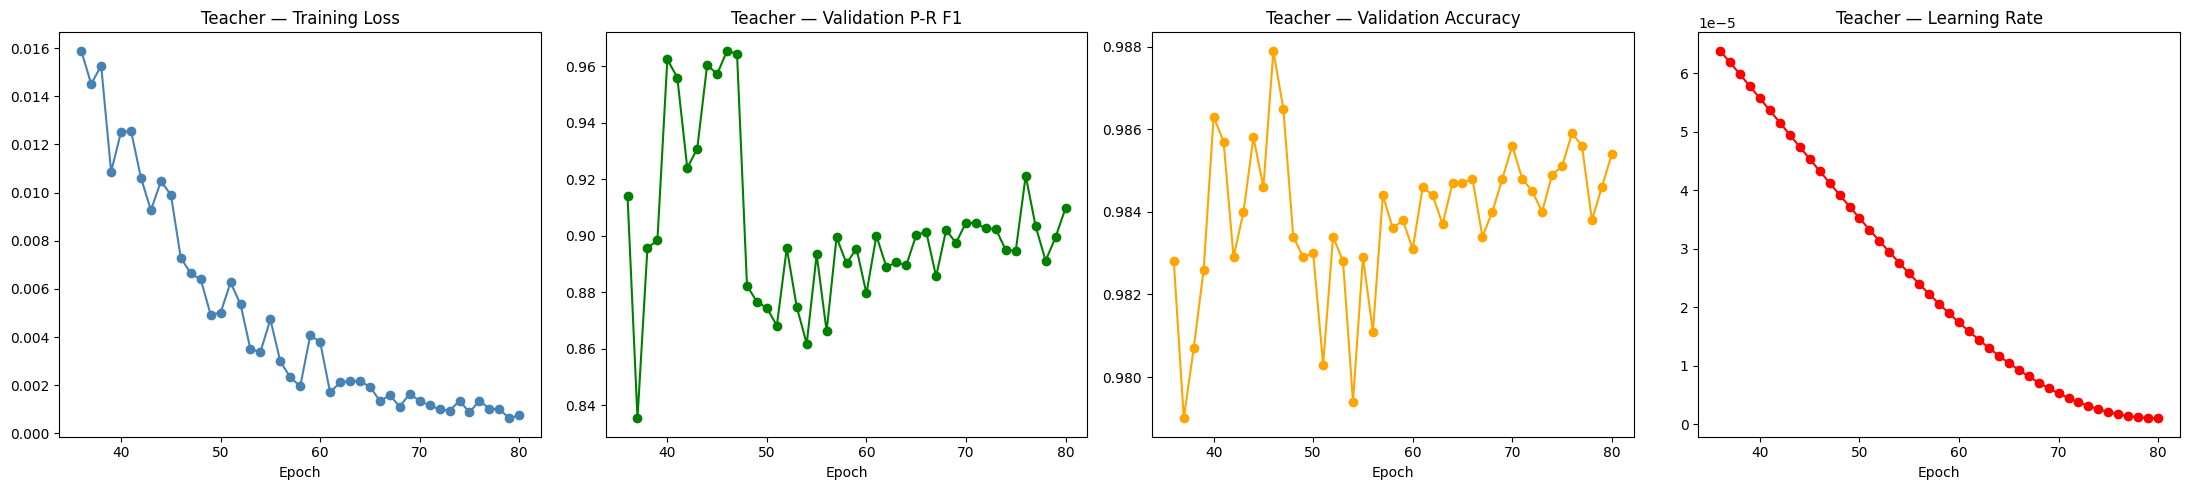

Saved → ./checkpoints/teacher_curves.png
GPU memory after cleanup: 773.7 MB allocated


In [17]:
print("=" * 60)
print("PHASE 1: Training OCT Teacher (FLAIR backbone)")
print(f"Effective batch = {batch_size} x {ACCUM_STEPS} = {batch_size * ACCUM_STEPS}")
print("=" * 60)

teacher_model     = ConceptModel(num_classes, concept_texts).to(device)
optimizer_teacher = optim.AdamW(teacher_model.parameters(), lr=1e-4, weight_decay=1e-4)

warmup_t    = LinearLR(optimizer_teacher, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine_t    = CosineAnnealingLR(optimizer_teacher, T_max=teacher_epochs - 5, eta_min=1e-6)
scheduler_t = SequentialLR(optimizer_teacher,
                            schedulers=[warmup_t, cosine_t],
                            milestones=[5])

scaler_t = GradScaler()

start_epoch_teacher = load_latest_checkpoint(
    teacher_model, optimizer_teacher, scheduler_t, phase="teacher"
)

teacher_results = []

for epoch in range(start_epoch_teacher, teacher_epochs + 1):
    teacher_model.train()
    epoch_loss = 0.0
    optimizer_teacher.zero_grad()

    for step, batch in enumerate(tqdm(oct_train_loader, desc=f"Teacher Epoch {epoch:2d}")):
        imgs   = batch['image'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        with autocast():
            logits, _ = teacher_model(imgs)
            loss = F.cross_entropy(logits, labels, weight=class_weights) / ACCUM_STEPS

        scaler_t.scale(loss).backward()
        epoch_loss += loss.item() * ACCUM_STEPS * imgs.size(0)

        if (step + 1) % ACCUM_STEPS == 0:
            scaler_t.unscale_(optimizer_teacher)
            torch.nn.utils.clip_grad_norm_(teacher_model.parameters(), max_norm=1.0)
            scaler_t.step(optimizer_teacher)
            scaler_t.update()
            optimizer_teacher.zero_grad()

    # Handle leftover steps
    if (step + 1) % ACCUM_STEPS != 0:
        scaler_t.unscale_(optimizer_teacher)
        torch.nn.utils.clip_grad_norm_(teacher_model.parameters(), max_norm=1.0)
        scaler_t.step(optimizer_teacher)
        scaler_t.update()
        optimizer_teacher.zero_grad()

    scheduler_t.step()
    epoch_loss /= len(oct_train_dataset)

    metrics = evaluate(teacher_model, oct_val_loader, device, phase="Teacher Val")
    teacher_results.append({
        "Epoch": epoch, "Train_Loss": epoch_loss,
        "LR": scheduler_t.get_last_lr()[0], **metrics
    })

    print(f"Teacher {epoch:2d} | LR: {scheduler_t.get_last_lr()[0]:.2e} | "
          f"Train Loss: {epoch_loss:.4f} | Val Loss: {metrics['Val_Loss']:.4f} | "
          f"Acc: {metrics['Accuracy']:.4f} | P-R F1: {metrics['P-R F1']:.4f}")

    if epoch % 5 == 0 or epoch == teacher_epochs:
        torch.save({
            'epoch':           epoch,
            'model_state':     teacher_model.state_dict(),
            'optimizer_state': optimizer_teacher.state_dict(),
        }, f"{CHECKPOINT_DIR}/teacher_latest.pth")
        torch.save(scheduler_t.state_dict(),
                   f"{CHECKPOINT_DIR}/teacher_scheduler.pth")
        torch.save(teacher_model.state_dict(),
                   f"{CHECKPOINT_DIR}/teacher_epoch_{epoch}.pth")
        print(f"   → Checkpoint saved (epoch {epoch})")

torch.save(teacher_model.state_dict(), f"{CHECKPOINT_DIR}/oct_teacher_final.pth")
print("Teacher training complete!")
plot_curves(teacher_results, "Teacher")

# Free GPU memory before student phase
del optimizer_teacher, scaler_t
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory after cleanup: {torch.cuda.memory_allocated()/1024**2:.1f} MB allocated")

PHASE 2: Training Fundus Student (FLAIR backbone)
Effective batch = 4 x 16 = 64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Student Epoch   1: 100%|██████████████████████████████████████████████████████████████████| 8709/8709 [16:17<00:00,  8.91it/s]
                                                                                                                              

Student   1 | LR: 2.80e-05 | Train Loss: 11.1370 | Val Loss: 1.8977 | Acc: 0.6144 | P-R F1: 0.1345
   → New best model! (P-R F1 = 0.1345)


...

Student  98 | LR: 1.11e-06 | Train Loss: 1.8992 | Val Loss: 0.6702 | Acc: 0.8100 | P-R F1: 0.4489


Student Epoch  99: 100%|████████████████████████████████████████████████████████████████████| 8709/8709 [10:53<00:00, 13.33it/s]
                                                                                                                                

Student  99 | LR: 1.03e-06 | Train Loss: 1.8257 | Val Loss: 0.6623 | Acc: 0.8129 | P-R F1: 0.4614


Student Epoch 100: 100%|████████████████████████████████████████████████████████████████████| 8709/8709 [11:04<00:00, 13.10it/s]
                                                                                                                                

Student 100 | LR: 1.00e-06 | Train Loss: 1.8445 | Val Loss: 0.6618 | Acc: 0.8111 | P-R F1: 0.4218

Best student: epoch 83, P-R F1 = 0.5190


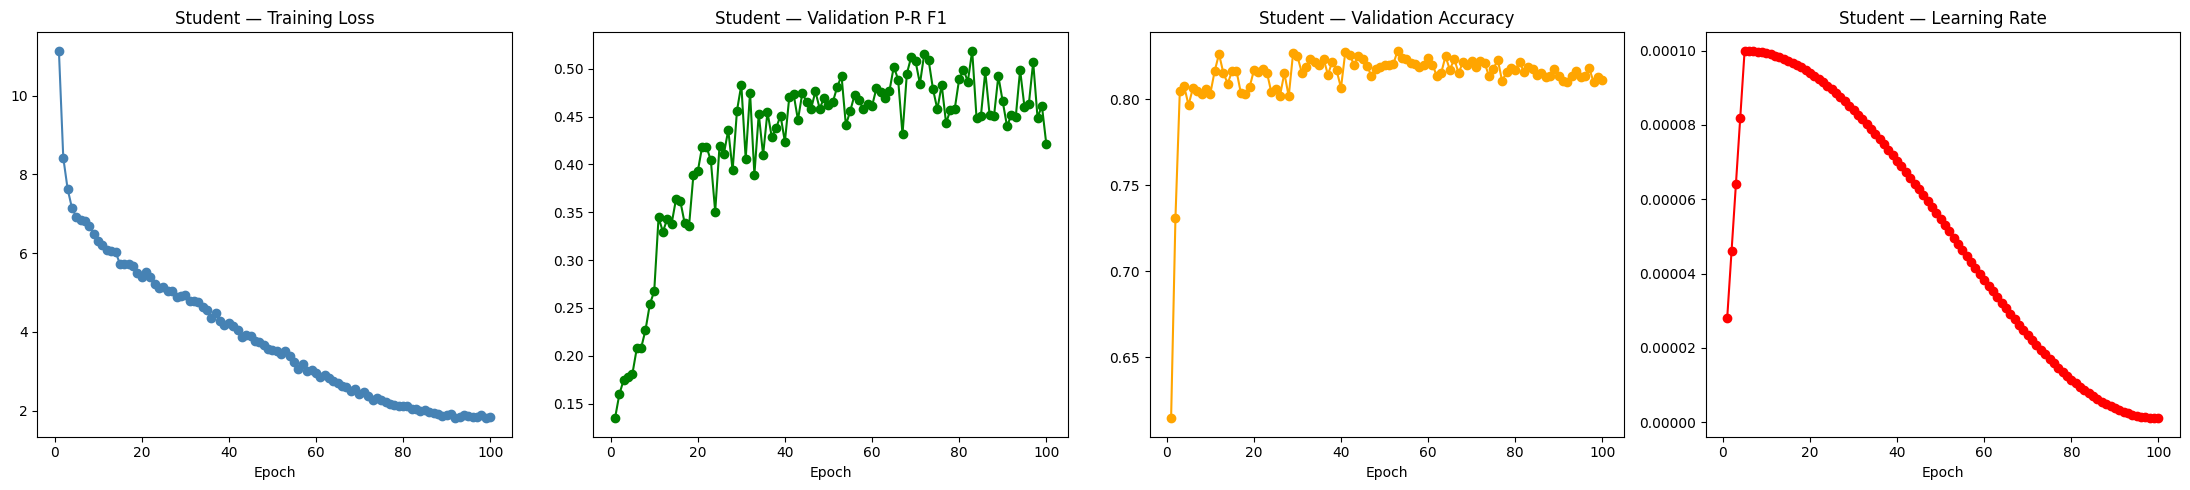

Saved → ./checkpoints/student_curves.png


In [18]:
print("=" * 60)
print("PHASE 2: Training Fundus Student (FLAIR backbone)")
print(f"Effective batch = {batch_size} x {ACCUM_STEPS} = {batch_size * ACCUM_STEPS}")
print("=" * 60)

# Load frozen teacher
teacher_model = ConceptModel(num_classes, concept_texts).to(device)
teacher_model.load_state_dict(
    torch.load(f"{CHECKPOINT_DIR}/oct_teacher_final.pth",
               map_location=device, weights_only=True)
)
for p in teacher_model.parameters():
    p.requires_grad = False
teacher_model.eval()

student_model     = ConceptModel(num_classes, concept_texts).to(device)
optimizer_student = optim.AdamW(student_model.parameters(), lr=1e-4, weight_decay=1e-4)

warmup_s    = LinearLR(optimizer_student, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine_s    = CosineAnnealingLR(optimizer_student, T_max=student_epochs - 5, eta_min=1e-6)
scheduler_s = SequentialLR(optimizer_student,
                            schedulers=[warmup_s, cosine_s],
                            milestones=[5])

scaler_s = GradScaler()

start_epoch_student = load_latest_checkpoint(
    student_model, optimizer_student, scheduler_s, phase="student"
)

student_results = []
best_pr_f1  = 0.0
best_epoch  = 0

for epoch in range(start_epoch_student, student_epochs + 1):
    student_model.train()
    epoch_loss = 0.0
    optimizer_student.zero_grad()

    total_steps  = min(len(fundus_train_loader), len(oct_train_loader))
    paired_iter  = zip(fundus_train_loader, oct_train_loader)

    for step, (batch_f, batch_o) in enumerate(tqdm(paired_iter,
                                                     desc=f"Student Epoch {epoch:3d}",
                                                     total=total_steps)):
        f_imgs   = batch_f['image'].to(device, non_blocking=True)
        o_imgs   = batch_o['image'].to(device, non_blocking=True)
        labels_f = batch_f['label'].to(device, non_blocking=True)
        labels_o = batch_o['label'].to(device, non_blocking=True)

        with autocast():
            s_logits, s_f = student_model(f_imgs)
            with torch.no_grad():
                _, s_o = teacher_model(o_imgs)

            L_cls    = F.cross_entropy(s_logits, labels_f, weight=class_weights)
            L_gpd    = gpd_loss(s_f, labels_f, s_o, labels_o)
            L_lcd    = lcd_loss(s_f, labels_f, s_o, labels_o, tau=tau)
            loss     = (L_cls + alpha * L_gpd + beta * L_lcd) / ACCUM_STEPS

        scaler_s.scale(loss).backward()
        epoch_loss += loss.item() * ACCUM_STEPS * f_imgs.size(0)

        if (step + 1) % ACCUM_STEPS == 0:
            scaler_s.unscale_(optimizer_student)
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
            scaler_s.step(optimizer_student)
            scaler_s.update()
            optimizer_student.zero_grad()

    # Handle leftover steps
    if (step + 1) % ACCUM_STEPS != 0:
        scaler_s.unscale_(optimizer_student)
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        scaler_s.step(optimizer_student)
        scaler_s.update()
        optimizer_student.zero_grad()

    scheduler_s.step()
    epoch_loss /= len(fundus_train_dataset)

    metrics = evaluate(student_model, fundus_val_loader, device, phase="Student Val")
    student_results.append({
        "Epoch": epoch, "Train_Loss": epoch_loss,
        "LR": scheduler_s.get_last_lr()[0], **metrics
    })

    print(f"Student {epoch:3d} | LR: {scheduler_s.get_last_lr()[0]:.2e} | "
          f"Train Loss: {epoch_loss:.4f} | Val Loss: {metrics['Val_Loss']:.4f} | "
          f"Acc: {metrics['Accuracy']:.4f} | P-R F1: {metrics['P-R F1']:.4f}")

    if metrics['P-R F1'] > best_pr_f1:
        best_pr_f1 = metrics['P-R F1']
        best_epoch  = epoch
        torch.save(student_model.state_dict(),
                   f"{CHECKPOINT_DIR}/student_best.pth")
        print(f"   → New best model! (P-R F1 = {best_pr_f1:.4f})")

    if epoch % 5 == 0 or epoch == student_epochs:
        torch.save({
            'epoch':           epoch,
            'model_state':     student_model.state_dict(),
            'optimizer_state': optimizer_student.state_dict(),
        }, f"{CHECKPOINT_DIR}/student_latest.pth")
        torch.save(scheduler_s.state_dict(),
                   f"{CHECKPOINT_DIR}/student_scheduler.pth")

print(f"\nBest student: epoch {best_epoch}, P-R F1 = {best_pr_f1:.4f}")
plot_curves(student_results, "Student")

In [10]:
import torch
torch.cuda.empty_cache()

In [13]:
def find_checkpoint():
    candidates = [
        os.path.join(CHECKPOINT_DIR, "student_best.pth"),       # ← epoch 83 best
        os.path.join(CHECKPOINT_DIR, "student_epoch_83.pth"),
        os.path.join(CHECKPOINT_DIR, "student_latest.pth"),
        os.path.join(CHECKPOINT_DIR, "student_epoch_80.pth"),
    ]
    for path in candidates:
        if os.path.exists(path):
            ckpt = torch.load(path, map_location="cpu")
            # Full checkpoint dict has 'epoch' key; state-dict-only files don't
            epoch_in_ckpt = ckpt.get("epoch", "unknown") if isinstance(ckpt, dict) else "state_dict_only"
            print(f"Found checkpoint: {path}  (epoch recorded: {epoch_in_ckpt})")
            return path, ckpt
    raise FileNotFoundError(
        "No suitable student checkpoint found. Check CHECKPOINT_DIR path."
    )
 
ckpt_path, ckpt = find_checkpoint()

Found checkpoint: ./checkpoints/student_best.pth  (epoch recorded: unknown)


In [15]:
student_model = ConceptModel(num_classes, concept_texts).to(device)
 
# Load weights (handle both full-checkpoint dict and bare state-dict)
if isinstance(ckpt, dict) and "model_state" in ckpt:
    student_model.load_state_dict(ckpt["model_state"])
    print(f"Loaded model_state from checkpoint (epoch {ckpt.get('epoch','?')})")
else:
    student_model.load_state_dict(ckpt)
    print("Loaded bare state-dict from checkpoint")
 
student_model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded bare state-dict from checkpoint


ConceptModel(
  (flair): FLAIRModel(
    (vision_model): VisionModel(
      (model): ResNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=

In [16]:
fundus_img_dir = os.path.join(DATA_ROOT, "assemble/train/ImageData/cfp-clahe-224x224")
fundus_dev_lbl = os.path.join(DATA_ROOT, "assemble/dev/large9cls.txt")
 
val_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=FLAIR_MEAN, std=FLAIR_STD),
])
 
class MultiEyeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
 
    def __len__(self):
        return len(self.image_paths)
 
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return {'image': img, 'label': torch.tensor(self.labels[idx], dtype=torch.long)}
 
def load_paths_and_labels(lbl_file, img_dir):
    paths, labels = [], []
    with open(lbl_file, 'r') as f:
        for line in f:
            parts  = line.strip().split()
            img_id = parts[0]
            label  = int(parts[1])
            for ext in ['.png', '.jpg', '.jpeg']:
                p = os.path.join(img_dir, img_id + ext)
                if os.path.exists(p):
                    paths.append(p)
                    labels.append(label)
                    break
    return paths, labels
 
fundus_val_paths, fundus_val_labels = load_paths_and_labels(fundus_dev_lbl, fundus_img_dir)
print(f"Fundus val samples: {len(fundus_val_paths)}")
 
fundus_val_dataset = MultiEyeDataset(fundus_val_paths, fundus_val_labels, val_transform)
fundus_val_loader  = DataLoader(fundus_val_dataset, batch_size=batch_size,
                                shuffle=False, num_workers=2, pin_memory=False)

Fundus val samples: 11601


In [17]:
metrics = evaluate(student_model, fundus_val_loader, device, phase="Student Eval")
metrics

{'Precision': 0.5229,
 'Recall': 0.544,
 'Specificity': np.float64(0.955),
 'P-R F1': 0.519,
 'S-S F1': np.float64(0.6366),
 'MAP': 0.5212,
 'Accuracy': 0.819,
 'Kappa': 0.6181,
 'Val_Loss': 0.6234}